# Phase 4: Machine Learning Development

## Objective

The objective of this phase is to develop, evaluate, and optimize machine learning models for predicting loan risk. The processed dataset from Phase 3 is used to train multiple classification algorithms, compare their performance, and select the best-performing model for deployment.

## Workflow

* Load the processed dataset
* Perform train-test split
* Train baseline model
* Evaluate model performance
* Train multiple machine learning models
* Compare model performance
* Perform cross-validation
* Tune hyperparameters
* Analyze feature importance
* Save the best-performing model


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import(
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.pipeline import Pipeline

import joblib

from pathlib import Path

ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)


In [2]:
df = pd.read_csv("../data/processed/loan_data_processed.csv")

In [3]:
df.shape

(1306387, 92)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1306387 entries, 0 to 1306386
Data columns (total 92 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   loan_amnt                       1306387 non-null  int64  
 1   funded_amnt                     1306387 non-null  int64  
 2   funded_amnt_inv                 1306387 non-null  float64
 3   term                            1306387 non-null  int64  
 4   int_rate                        1306387 non-null  float64
 5   installment                     1306387 non-null  float64
 6   grade                           1306387 non-null  int64  
 7   sub_grade                       1306387 non-null  int64  
 8   emp_length                      1306387 non-null  str    
 9   home_ownership                  1306387 non-null  int64  
 10  annual_inc                      1306387 non-null  float64
 11  verification_status             1306387 non-null  int64  
 12  loan_status

In [5]:
df["loan_status"].value_counts(normalize=True)

df.drop(columns=["emp_length", "zip_code"], inplace=True)

In [6]:
X = df.drop(columns="loan_status")
y = df["loan_status"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [8]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(1045109, 89)
(261278, 89)
loan_status
0    0.799105
1    0.200895
Name: proportion, dtype: float64
loan_status
0    0.799103
1    0.200897
Name: proportion, dtype: float64


In [9]:
from sklearn.dummy import DummyClassifier

dm = DummyClassifier(strategy="most_frequent")

dm.fit(X_train, y_train)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.8,0.2]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](89,)","['loan_amnt','funded_amnt','funded_amnt_inv',...,'loan_to_income_ratio', 'installment_to_income_ratio','emp_length_numeric']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,89
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [10]:
y_pred = dm.predict(X_test)
y_prob = dm.predict_proba(X_test)[:, 1] 

In [11]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7991
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC AUC  : 0.5000


In [12]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89    208788
           1       0.00      0.00      0.00     52490

    accuracy                           0.80    261278
   macro avg       0.40      0.50      0.44    261278
weighted avg       0.64      0.80      0.71    261278



In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42,
                        max_iter=1000,
                        )

lr.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [14]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:, 1]

In [15]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7981
Precision: 0.3626
Recall   : 0.0066
F1 Score : 0.0130
ROC AUC  : 0.6344


In [16]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89    208788
           1       0.36      0.01      0.01     52490

    accuracy                           0.80    261278
   macro avg       0.58      0.50      0.45    261278
weighted avg       0.71      0.80      0.71    261278



In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

Confusion Matrix
[[208178    610]
 [ 52143    347]]


In [18]:
model_results = {}

model_results['LogisticRegression'] ={
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, y_prob)
}

In [19]:
model_results 

{'LogisticRegression': {'Accuracy': 0.7980962805900229,
  'Precision': 0.3625914315569488,
  'Recall': 0.006610783006286911,
  'F1 Score': 0.012984826089396972,
  'ROC AUC': 0.6344393396271105}}

In [20]:
from sklearn.preprocessing import StandardScaler
lr_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])


In [21]:
lr_scaled.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](89,)","['loan_amnt','funded_amnt','funded_amnt_inv',...,'loan_to_income_ratio', 'installment_to_income_ratio','emp_length_numeric']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,89
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [22]:
y_pred_scaled = lr_scaled.predict(X_test)
y_prob_scaled = lr_scaled.predict_proba(X_test)[:, 1]

In [23]:
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
precision_scaled = precision_score(y_test, y_pred_scaled, zero_division=0)
recall_scaled = recall_score(y_test, y_pred_scaled, zero_division=0)
f1_scaled = f1_score(y_test, y_pred_scaled, zero_division=0)
roc_auc_scaled = roc_auc_score(y_test, y_prob_scaled)

print(f"Accuracy : {accuracy_scaled:.4f}")
print(f"Precision: {precision_scaled:.4f}")
print(f"Recall   : {recall_scaled:.4f}")
print(f"F1 Score : {f1_scaled:.4f}")
print(f"ROC AUC  : {roc_auc_scaled:.4f}")

Accuracy : 0.8013
Precision: 0.5317
Recall   : 0.0934
F1 Score : 0.1589
ROC AUC  : 0.7163


In [24]:
print(classification_report(
    y_test,
    y_pred_scaled,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    208788
           1       0.53      0.09      0.16     52490

    accuracy                           0.80    261278
   macro avg       0.67      0.54      0.52    261278
weighted avg       0.76      0.80      0.74    261278



In [25]:
cm_scaled = confusion_matrix(y_test, y_pred_scaled)

print(cm_scaled)

[[204471   4317]
 [ 47588   4902]]


In [26]:

model_results["Logistic Regression + StandardScaler"] = {
    "Accuracy": accuracy_scaled,
    "Precision": precision_scaled,
    "Recall": recall_scaled,
    "F1": f1_scaled,
    "ROC-AUC": roc_auc_scaled
}

In [27]:
model_results

{'LogisticRegression': {'Accuracy': 0.7980962805900229,
  'Precision': 0.3625914315569488,
  'Recall': 0.006610783006286911,
  'F1 Score': 0.012984826089396972,
  'ROC AUC': 0.6344393396271105},
 'Logistic Regression + StandardScaler': {'Accuracy': 0.8013418657521874,
  'Precision': 0.5317279531402538,
  'Recall': 0.0933892169937131,
  'F1': 0.15887471843653275,
  'ROC-AUC': 0.7162609822476218}}

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42,
                            n_estimators=100,
                            n_jobs=-1,)

In [29]:
%%time 

rf.fit(X_train, y_train)

CPU times: total: 23min 31s
Wall time: 1min 53s


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [30]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [31]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")
print(f"ROC AUC  : {roc_auc_rf:.4f}")

Accuracy : 0.8025
Precision: 0.5574
Recall   : 0.0822
F1 Score : 0.1433
ROC AUC  : 0.7131


In [32]:
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    208788
           1       0.56      0.08      0.14     52490

    accuracy                           0.80    261278
   macro avg       0.68      0.53      0.52    261278
weighted avg       0.76      0.80      0.74    261278



In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[205363   3425]
 [ 48176   4314]]


In [34]:
model_results["Random Forest"] = {
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1": f1_rf,
    "ROC-AUC": roc_auc_rf
}

In [35]:
model_results

{'LogisticRegression': {'Accuracy': 0.7980962805900229,
  'Precision': 0.3625914315569488,
  'Recall': 0.006610783006286911,
  'F1 Score': 0.012984826089396972,
  'ROC AUC': 0.6344393396271105},
 'Logistic Regression + StandardScaler': {'Accuracy': 0.8013418657521874,
  'Precision': 0.5317279531402538,
  'Recall': 0.0933892169937131,
  'F1': 0.15887471843653275,
  'ROC-AUC': 0.7162609822476218},
 'Random Forest': {'Accuracy': 0.8025053774140953,
  'Precision': 0.557436361286988,
  'Recall': 0.08218708325395313,
  'F1': 0.14325325009546896,
  'ROC-AUC': 0.7131498625477487}}

In [36]:
train_score = rf.score(X_train, y_train)
test_score = rf.score(X_test, y_test)

print(f"Train Accuracy: {train_score:.4f}")
print(f"Test Accuracy : {test_score:.4f}")

Train Accuracy: 1.0000
Test Accuracy : 0.8025


In [37]:
import xgboost
print(xgboost.__version__)

3.3.0


In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42,
                    n_estimators=100,
                    n_jobs=-1,
                    eval_metric="logloss",
                    max_depth=6,
                    learning_rate=0.1
                    )

In [39]:
%%time 

xgb.fit(X_train, y_train)

CPU times: total: 1min 36s
Wall time: 7.59 s


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [40]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [41]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb, zero_division=0)
recall_xgb = recall_score(y_test, y_pred_xgb, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")
print(f"ROC AUC  : {roc_auc_xgb:.4f}")

Accuracy : 0.8046
Precision: 0.5822
Recall   : 0.0971
F1 Score : 0.1664
ROC AUC  : 0.7305


In [42]:
print(classification_report(
    y_test,
    y_pred_xgb,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89    208788
           1       0.58      0.10      0.17     52490

    accuracy                           0.80    261278
   macro avg       0.70      0.54      0.53    261278
weighted avg       0.77      0.80      0.74    261278



In [43]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print(cm_xgb)

[[205131   3657]
 [ 47394   5096]]


In [44]:
train_score_xgb = xgb.score(X_train, y_train)
test_score_xgb = xgb.score(X_test, y_test)

print(f"Train Accuracy: {train_score_xgb:.4f}")
print(f"Test Accuracy : {test_score_xgb:.4f}")

Train Accuracy: 0.8070
Test Accuracy : 0.8046


In [45]:
model_results["XGBoost"] = {
    "Accuracy": accuracy_xgb,
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "F1": f1_xgb,
    "ROC-AUC": roc_auc_xgb
}

In [46]:
results_df = pd.DataFrame(model_results).T.sort_values(by="ROC-AUC", ascending=False)

In [47]:
results_df

,Accuracy,Precision,Recall,F1 Score,ROC AUC,F1,ROC-AUC
XGBoost,0.804610,0.582200,0.097085,NaN,NaN,0.166419,0.730491
Logistic Regression + StandardScaler,0.801342,0.531728,0.093389,NaN,NaN,0.158875,0.716261
Random Forest,0.802505,0.557436,0.082187,NaN,NaN,0.143253,0.713150
LogisticRegression,0.798096,0.362591,0.006611,0.012985,0.634439,NaN,NaN


In [48]:
model_results["LogisticRegression"] = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

In [49]:
results_df = pd.DataFrame(model_results).T.sort_values(by="ROC-AUC", ascending=False)

In [50]:
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
XGBoost,0.804610,0.582200,0.097085,0.166419,0.730491
Logistic Regression + StandardScaler,0.801342,0.531728,0.093389,0.158875,0.716261
Random Forest,0.802505,0.557436,0.082187,0.143253,0.713150
LogisticRegression,0.798096,0.362591,0.006611,0.012985,0.634439


In [51]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [52]:
%%time

xgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
CPU times: total: 3min 33s
Wall time: 7min 16s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [53]:
print('Best parameters found: ', xgb_search.best_params_)
print('Best ROC-AUC score: ', xgb_search.best_score_)

Best parameters found:  {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}
Best ROC-AUC score:  0.7351253935789761


In [54]:
best_xgb = xgb_search.best_estimator_

In [55]:
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

In [56]:
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best, zero_division=0)
recall_best = recall_score(y_test, y_pred_best, zero_division=0)
f1_best = f1_score(y_test, y_pred_best, zero_division=0)
roc_auc_best = roc_auc_score(y_test, y_prob_best)

print(f"Accuracy : {accuracy_best:.4f}")
print(f"Precision: {precision_best:.4f}")
print(f"Recall   : {recall_best:.4f}")
print(f"F1 Score : {f1_best:.4f}")
print(f"ROC AUC  : {roc_auc_best:.4f}")

Accuracy : 0.8046
Precision: 0.5638
Recall   : 0.1218
F1 Score : 0.2003
ROC AUC  : 0.7361


In [57]:
print(classification_report(
    y_test,
    y_pred_best,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89    208788
           1       0.56      0.12      0.20     52490

    accuracy                           0.80    261278
   macro avg       0.69      0.55      0.54    261278
weighted avg       0.76      0.80      0.75    261278



In [58]:
cm_best = confusion_matrix(y_test, y_pred_best)
print(cm_best)

[[203841   4947]
 [ 46097   6393]]


In [59]:
train_score_best = best_xgb.score(X_train, y_train)
test_score_best = best_xgb.score(X_test, y_test)

print(f"Train Accuracy: {train_score_best:.4f}")
print(f"Test Accuracy : {test_score_best:.4f}")

Train Accuracy: 0.8115
Test Accuracy : 0.8046


In [60]:
model_results["XGBoost (Tuned)"] = {
    "Accuracy": accuracy_best,
    "Precision": precision_best,
    "Recall": recall_best,
    "F1": f1_best,
    "ROC-AUC": roc_auc_best
}

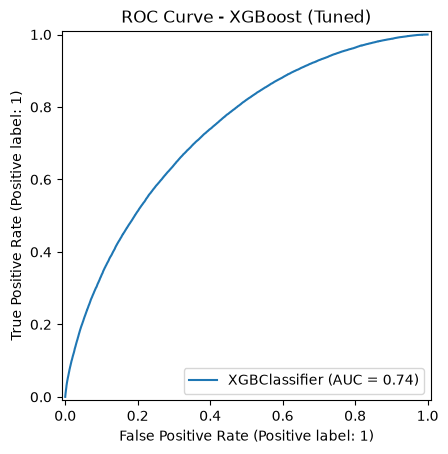

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

RocCurveDisplay.from_estimator(best_xgb, X_test, y_test)
plt.title("ROC Curve - XGBoost (Tuned)")
plt.show()

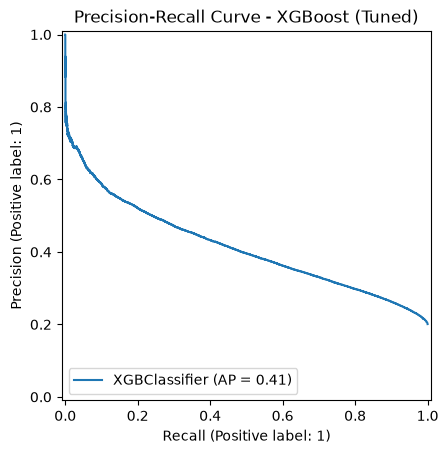

In [62]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(best_xgb, X_test, y_test)
plt.title("Precision-Recall Curve - XGBoost (Tuned)")
plt.show()

In [63]:
y_prob = best_xgb.predict_proba(X_test)[:,1]

In [64]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)


In [65]:
threshold_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1]
})

In [66]:
threshold_df.head()

,Threshold,Precision,Recall
0,0.002253,0.200897,1.0
1,0.003272,0.200898,1.0
2,0.003900,0.200899,1.0
3,0.003940,0.200899,1.0
4,0.004001,0.200900,1.0


In [67]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

In [68]:
feature_importance.head(20)

,Feature,Importance
7,sub_grade,0.275916
6,grade,0.243372
3,term,0.055268
8,home_ownership,0.024905
47,acc_open_past_24mths,0.015232
57,mort_acc,0.014705
86,loan_to_income_ratio,0.014649
64,num_actv_rev_tl,0.013481
40,open_rv_24m,0.013387
36,mths_since_rcnt_il,0.012482


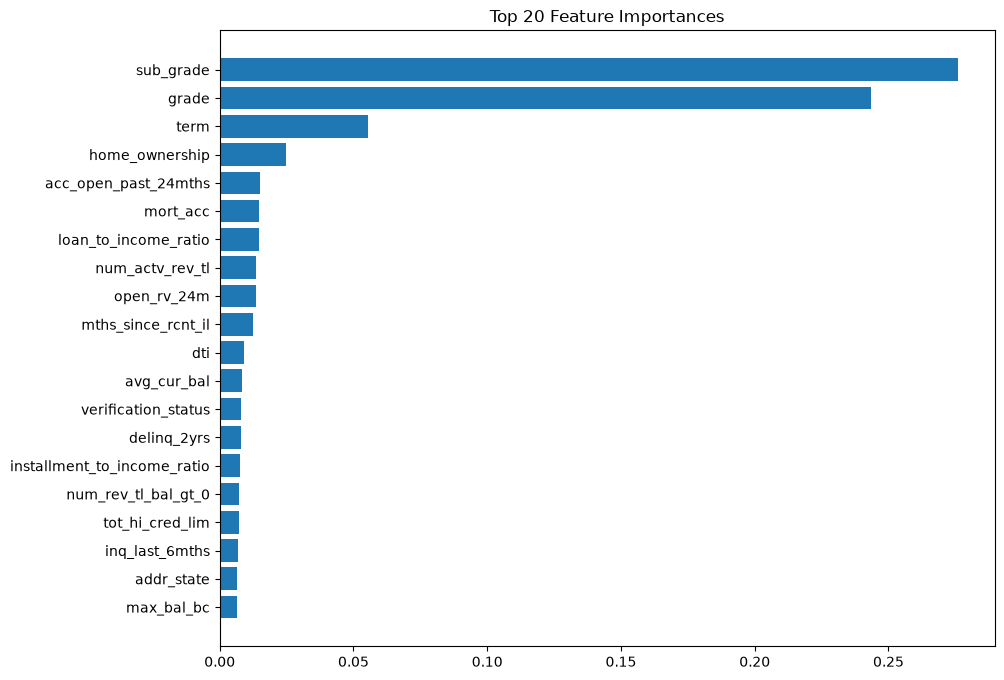

In [69]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"][:20],
    feature_importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importances")

plt.show()

### Threshold Optimization
Refered ChatGpt Because i am not done threshold optimization before..

In [70]:
threshold_df["F1"] = (
    2
    * threshold_df["Precision"]
    * threshold_df["Recall"]
) / (
    threshold_df["Precision"]
    + threshold_df["Recall"]
)  # Create F1 for every threshold

In [71]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold  #step 2

Threshold    0.225373
Precision    0.356224
Recall       0.618651
F1           0.452116
Name: 168802, dtype: float64

In [72]:
best_threshold_value = best_threshold["Threshold"]

y_pred_optimal = (
    y_prob >= best_threshold_value
).astype(int)  #step 3

In [73]:
print(classification_report(
    y_test,
    y_pred_optimal,
    zero_division=0
))

print(confusion_matrix(
    y_test,
    y_pred_optimal
)) #step 4

              precision    recall  f1-score   support

           0       0.88      0.72      0.79    208788
           1       0.36      0.62      0.45     52490

    accuracy                           0.70    261278
   macro avg       0.62      0.67      0.62    261278
weighted avg       0.78      0.70      0.72    261278

[[150102  58686]
 [ 20017  32473]]


In [74]:
OPTIMAL_THRESHOLD = float(best_threshold_value) #condiguration variable

In [75]:
%pip install "numpy<2.5"

Note: you may need to restart the kernel to use updated packages.


In [76]:
import shap 

explainer = shap.TreeExplainer(best_xgb)

In [77]:
X_sample = X_test.sample(
    n=2000,
    random_state=42
)

shap_values = explainer.shap_values(X_sample)

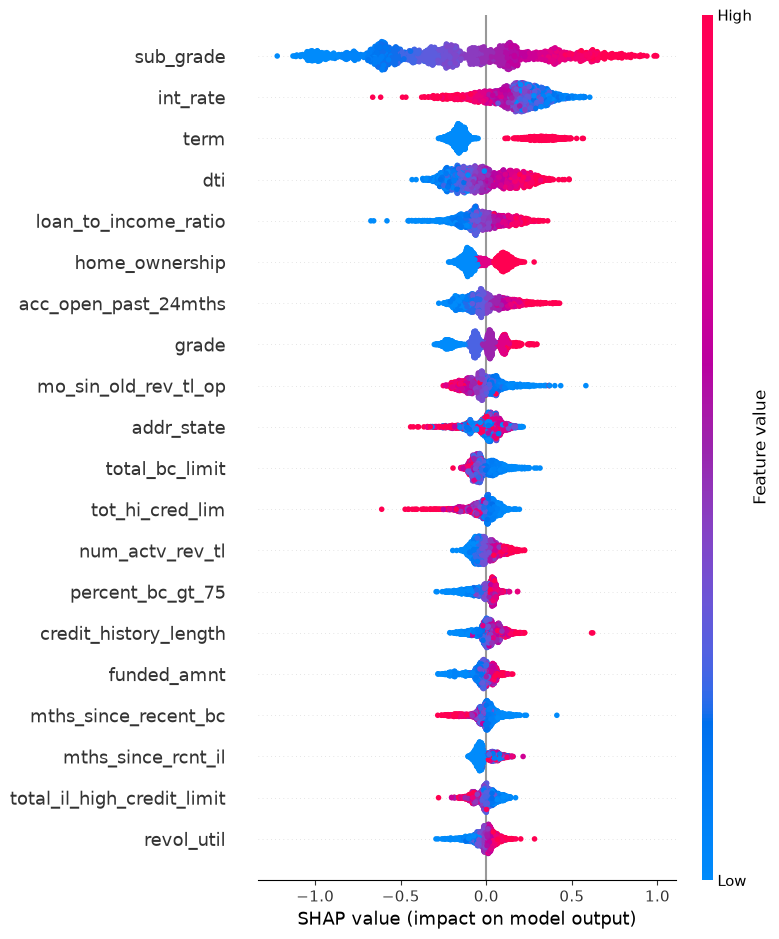

In [78]:
shap.summary_plot(
    shap_values,
    X_sample
)

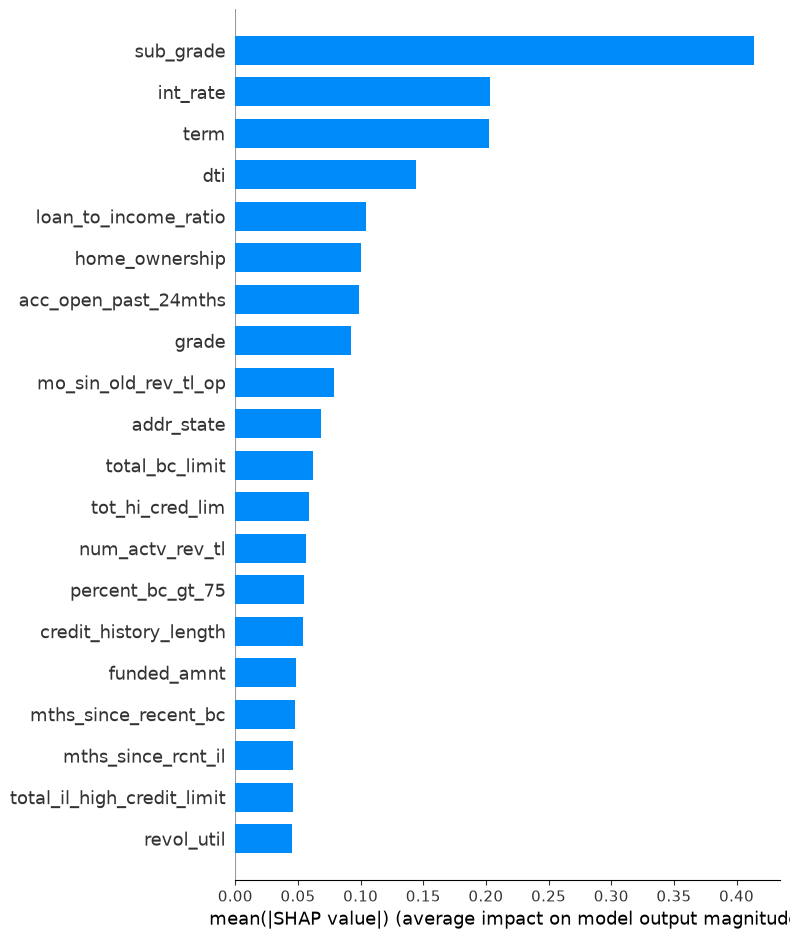

In [79]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

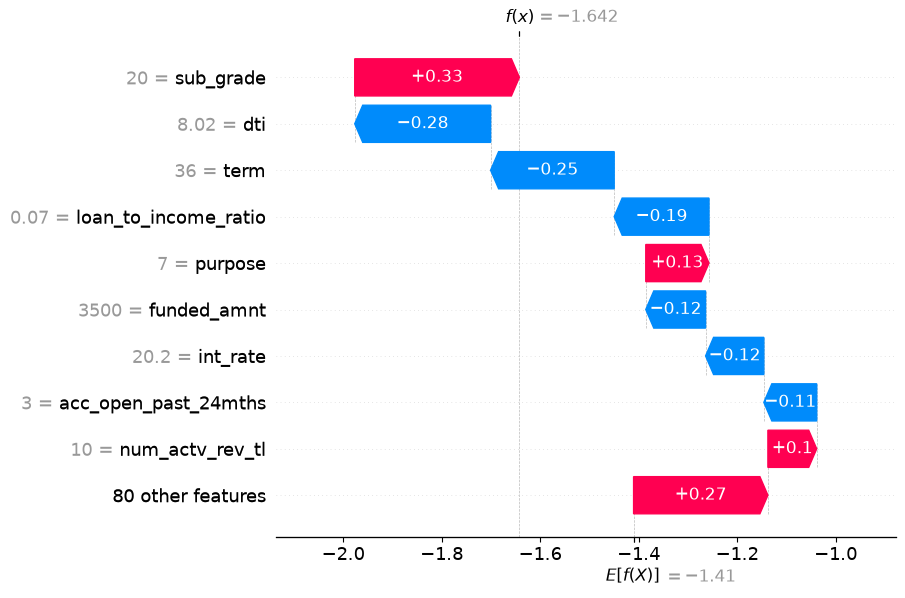

In [80]:
loan_index = 10

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[loan_index],
        base_values=explainer.expected_value,
        data=X_sample.iloc[loan_index],
        feature_names=X_sample.columns
    )
)

In [81]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[loan_index],
    X_sample.iloc[loan_index]
)

# Model Insights & Conclusion

## Overview

In this phase, multiple machine learning models were developed, evaluated, and compared to identify the most suitable model for predicting loan default risk. The evaluation focused not only on predictive performance but also on model generalization, business relevance, and explainability.

---

## Model Comparison

The following models were trained and evaluated:

* Dummy Classifier (Baseline)
* Logistic Regression
* Logistic Regression + StandardScaler
* Random Forest
* XGBoost (Baseline)
* Tuned XGBoost (RandomizedSearchCV)

Evaluation metrics included:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix
* Classification Report

Among all evaluated models, the tuned XGBoost classifier consistently achieved the strongest overall performance while maintaining excellent generalization on unseen data.

---

## Hyperparameter Tuning

Hyperparameter optimization was performed using **RandomizedSearchCV** with ROC-AUC as the optimization metric.

The tuned XGBoost model demonstrated improved performance compared to the baseline model, particularly in:

* Higher ROC-AUC
* Improved Recall
* Improved F1-Score
* Better balance between identifying default and non-default loans

The train and test accuracies remained very close, indicating minimal overfitting and good generalization.

---

## Threshold Optimization

Instead of relying on the default classification threshold of **0.5**, threshold optimization was performed using the Precision-Recall curve.

This significantly increased the model's ability to identify default loans.

Key observations:

* Recall increased substantially.
* F1-Score improved considerably.
* More high-risk borrowers were correctly identified.
* The threshold can now be adjusted based on future business requirements, allowing the organization to balance false positives and false negatives according to operational needs.

This demonstrates an important production practice where the decision threshold is chosen based on business objectives rather than relying on the framework default.

---

## Feature Importance

Feature importance analysis showed that the model primarily relied on meaningful financial and credit-related variables.

The most influential features included:

* sub_grade
* int_rate
* term
* dti
* loan_to_income_ratio
* home_ownership

Several engineered features also ranked among the top contributors, validating the effectiveness of the feature engineering process.

---

## SHAP Explainability

SHAP (SHapley Additive exPlanations) was used to improve model interpretability.

The explainability analysis provided:

* Global feature importance
* Local explanations for individual predictions
* Feature contribution visualization
* Decision transparency

SHAP confirmed that the model's predictions align with domain knowledge, increasing confidence in the model and making its decisions easier to interpret for both technical and business stakeholders.

---

## Final Model Selection

Based on the complete evaluation pipeline, the **Tuned XGBoost Classifier** was selected as the final production candidate because it provided:

* Best ROC-AUC
* Highest Recall after threshold optimization
* Strong F1-Score
* Minimal overfitting
* Excellent generalization
* High interpretability through SHAP

---

## Conclusion

The model development phase successfully produced a production-ready machine learning model for loan default prediction.

Beyond predictive performance, the workflow incorporated several enterprise machine learning practices, including:

* Baseline model comparison
* Hyperparameter tuning
* Threshold optimization
* Model validation
* Feature importance analysis
* SHAP explainability

These steps ensure that the selected model is not only accurate but also interpretable, reliable, and suitable for deployment within a real-world Loan Risk Intelligence Platform.

The next phase focuses on packaging the model, building an inference pipeline, developing a FastAPI service, and deploying the complete solution as a production-ready application.


In [82]:
joblib.dump(
    best_xgb,
    ARTIFACTS_DIR / "xgboost_model.pkl"
)

print("✅ Model saved successfully.")

✅ Model saved successfully.


In [83]:
joblib.dump(
    list(X_train.columns),
    ARTIFACTS_DIR / "model_features.pkl"
)
print('✅ Model features saved successfully.')

✅ Model features saved successfully.


In [84]:
joblib.dump(
    OPTIMAL_THRESHOLD,
    ARTIFACTS_DIR / "optimal_threshold.pkl"
)
print('✅ Optimal threshold saved successfully.')


✅ Optimal threshold saved successfully.


In [86]:
import json
metadata = {
    "model_name": "XGBoost Classifier",
    "model_version": "1.0.0",
    "problem_type": "Binary Classification",
    "target": "loan_status",
    "positive_class": "Default",
    "negative_class": "Non-Default",
    "roc_auc": float(roc_auc_best),
    "threshold": float(best_threshold_value)
}

with open(ARTIFACTS_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("✅ Model metadata saved successfully.")

✅ Model metadata saved successfully.
